# Risk Levels

**Models compared:**
1. LSTM (sequential, PyTorch)
2. GRU (sequential, PyTorch)
3. 1D CNN (sequential, PyTorch)
4. CNN-LSTM Hybrid (sequential, PyTorch)
5. Random Forest (flat)
6. Logistic Regression (flat)
7. XGBoost (flat)
8. LightGBM (flat)


In [2]:
import os
os.environ['OMP_NUM_THREADS']     = '1'
os.environ['OPENBLAS_NUM_THREADS']= '1'
os.environ['MKL_NUM_THREADS']     = '1'

In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = '/Users/ishashetye/Desktop/Be_Safe_On_the_Road/lstm_data2.csv'
SEQ_LEN   = 10
HORIZON   = 3

SEEDS = [42, 0, 1, 2, 3]

In [4]:
df = pd.read_csv(DATA_PATH)
df = df.sort_values(['car_id', 'frame_id']).reset_index(drop=True)

In [5]:
BEHAVIOURS = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9']
BEHAVIOUR_AGGRESSION = {
    'C0': 0.05, 'C1': 0.20, 'C2': 0.30, 'C3': 0.55, 'C4': 0.40,
    'C5': 0.50, 'C6': 0.65, 'C7': 0.35, 'C8': 0.45, 'C9': 0.80,
}

def instantaneous_risk(row):
    speed_term = min(row['speed_mph'] / 100.0, 1.0) * 0.40
    depth_term = max(0.0, (25 - row['Depth']) / 25.0) * 0.30
    behav_term = BEHAVIOUR_AGGRESSION[row['Behaviour class']] * 0.30
    return min(speed_term + depth_term + behav_term, 1.0)

df['inst_risk'] = df.apply(instantaneous_risk, axis=1)

def compute_future_risk(risks):
    r = risks.values
    fr = np.full(len(r), np.nan)
    for i in range(len(r) - HORIZON):
        fr[i] = r[i+1:i+1+HORIZON].max()
    return pd.Series(fr, index=risks.index)

df['future_risk'] = df.groupby('car_id')['inst_risk'].transform(compute_future_risk)
df = df.dropna(subset=['future_risk']).reset_index(drop=True)

In [6]:
LEVEL_ORDER = ['L1_VeryLow', 'L2_Low', 'L3_Moderate', 'L4_High', 'L5_Critical']

def to_level(s):
    if s <= 0.2: return 'L1_VeryLow'
    if s <= 0.4: return 'L2_Low'
    if s <= 0.6: return 'L3_Moderate'
    if s <= 0.8: return 'L4_High'
    return 'L5_Critical'

df['future_risk_class'] = df['future_risk'].apply(to_level)
print('Overall class distribution (note the imbalance — L5_Critical is tiny):')
print(df['future_risk_class'].value_counts().reindex(LEVEL_ORDER, fill_value=0))

Overall class distribution (note the imbalance — L5_Critical is tiny):
future_risk_class
L1_VeryLow     1051
L2_Low         3119
L3_Moderate    2629
L4_High        2322
L5_Critical     308
Name: count, dtype: int64


In [7]:
beh_dummies = pd.get_dummies(df['Behaviour class'], prefix='beh').astype(float)
for b in BEHAVIOURS:
    col = f'beh_{b}'
    if col not in beh_dummies.columns:
        beh_dummies[col] = 0.0
beh_dummies = beh_dummies[[f'beh_{b}' for b in BEHAVIOURS]]
df = pd.concat([df, beh_dummies], axis=1)

RAW_CONT_COLS = ['Depth', 'speed_mph']
BEH_COLS      = [f'beh_{b}' for b in BEHAVIOURS]
feature_cols  = RAW_CONT_COLS + BEH_COLS
N_CONT        = len(RAW_CONT_COLS)   # first N_CONT features are the continuous ones
print(f'{len(feature_cols)} feature columns: {feature_cols}')

12 feature columns: ['Depth', 'speed_mph', 'beh_C0', 'beh_C1', 'beh_C2', 'beh_C3', 'beh_C4', 'beh_C5', 'beh_C6', 'beh_C7', 'beh_C8', 'beh_C9']


In [8]:
class_to_idx = {c: i for i, c in enumerate(LEVEL_ORDER)}

def build_sequences(df_split, feature_cols, seq_len):
    X, y_cls, car_ids = [], [], []
    for car_id, group in df_split.groupby('car_id'):
        feats = group[feature_cols].values
        t_cls = group['future_risk_class'].values
        if len(group) < seq_len:
            continue
        for i in range(len(group) - seq_len + 1):
            X.append(feats[i:i+seq_len])
            y_cls.append(class_to_idx[t_cls[i+seq_len-1]])
            car_ids.append(car_id)
    return (np.array(X, dtype=np.float32),
            np.array(y_cls, dtype=np.int64),
            np.array(car_ids))

def fit_scaler_on_train(X_train, n_cont):
    scaler = MinMaxScaler()
    flat = X_train[:, :, :n_cont].reshape(-1, n_cont)
    scaler.fit(flat)
    return scaler

def apply_scaler(X, scaler, n_cont):
    X = X.copy()
    n_seq, seq_len, _ = X.shape
    flat = X[:, :, :n_cont].reshape(-1, n_cont)
    X[:, :, :n_cont] = scaler.transform(flat).reshape(n_seq, seq_len, n_cont)
    return X

def oversample_minority_classes(X, y, seed):
    rng = np.random.RandomState(seed)
    counts = np.bincount(y)
    max_count = counts.max()
    X_parts, y_parts = [X], [y]
    for c, count in enumerate(counts):
        if count == 0 or count == max_count:
            continue
        idx_c = np.where(y == c)[0]
        n_extra = max_count - count
        sample_idx = rng.choice(idx_c, size=n_extra, replace=True)
        X_parts.append(X[sample_idx])
        y_parts.append(np.full(n_extra, c, dtype=y.dtype))
    X_bal = np.concatenate(X_parts, axis=0)
    y_bal = np.concatenate(y_parts, axis=0)
    perm = rng.permutation(len(X_bal))
    return X_bal[perm], y_bal[perm]

def evaluate_classification(y_true_idx, y_pred_idx, name='', verbose=True):
    acc      = accuracy_score(y_true_idx, y_pred_idx)
    macro_f1 = f1_score(y_true_idx, y_pred_idx, average='macro')
    if verbose:
        y_true_lbl = [LEVEL_ORDER[i] for i in y_true_idx]
        y_pred_lbl = [LEVEL_ORDER[i] for i in y_pred_idx]
        print(f'\n===== {name} =====')
        print(f'Accuracy: {acc*100:.2f}% | Macro F1: {macro_f1:.3f}')
        print('\nClassification report:')
        print(classification_report(y_true_lbl, y_pred_lbl,
                                    labels=LEVEL_ORDER, zero_division=0))
    return acc, macro_f1

In [9]:
# ─── LSTM ───
class RiskLSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size=32, n_classes=5, dropout=0.4):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=1, batch_first=True)
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, n_classes),
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])

# ─── GRU ───
class RiskGRUClassifier(nn.Module):
    def __init__(self, input_size, hidden_size=32, n_classes=5, dropout=0.4):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers=1, batch_first=True)
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, n_classes),
        )
    def forward(self, x):
        out, _ = self.gru(x)
        return self.head(out[:, -1, :])

# ─── 1D CNN ───
class Risk1DCNNClassifier(nn.Module):
    def __init__(self, input_size, seq_len=10, n_classes=5, dropout=0.4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(input_size, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),  
        )
        self.head = nn.Sequential(
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, n_classes),
        )
    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.conv(x).squeeze(-1)  
        return self.head(x)

class RiskCNNLSTMClassifier(nn.Module):
    """1D CNN for local feature extraction followed by LSTM for temporal modelling."""
    def __init__(self, input_size, hidden_size=32, n_classes=5, dropout=0.4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(input_size, 64, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.lstm = nn.LSTM(64, hidden_size, num_layers=1, batch_first=True)
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, n_classes),
        )
    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.conv(x)           
        x = x.permute(0, 2, 1)    
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])

In [10]:
def train_sequential_model(model_class, model_kwargs,
                           X_train, y_train, X_val, y_val, X_test,
                           seed, num_epochs=80, patience=10, verbose=False):
    torch.manual_seed(seed)
    np.random.seed(seed)

    X_tr_t = torch.tensor(X_train); y_tr_t = torch.tensor(y_train)
    X_va_t = torch.tensor(X_val);   y_va_t = torch.tensor(y_val)
    X_te_t = torch.tensor(X_test)

    train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=64, shuffle=True)
    val_loader   = DataLoader(TensorDataset(X_va_t, y_va_t), batch_size=128)

    model     = model_class(**model_kwargs)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

    best_val, best_state, patience_left = float('inf'), None, patience
    for epoch in range(num_epochs):
        model.train()
        tl = 0.0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            tl += loss.item() * len(xb)
        tl /= len(train_loader.dataset)

        model.eval()
        with torch.no_grad():
            vl = sum(criterion(model(xb), yb).item() * len(xb) for xb, yb in val_loader)
            vl /= len(val_loader.dataset)

        if vl < best_val - 1e-5:
            best_val = vl
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_left = patience
        else:
            patience_left -= 1

        if verbose and ((epoch + 1) % 5 == 0 or epoch == 0):
            print(f'  Epoch {epoch+1:3d} | train {tl:.4f} | val {vl:.4f} | best {best_val:.4f} | pat {patience_left}')
        if patience_left <= 0:
            if verbose:
                print(f'  Early stopping at epoch {epoch+1}')
            break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        preds = model(X_te_t).argmax(dim=1).numpy()
    return preds

In [11]:
MODEL_NAMES = [
    'LSTM', 'GRU', '1D CNN', 'CNN-LSTM',
    'Random Forest', 'Logistic Regression', 'XGBoost', 'LightGBM',
]

def run_experiment(seed, verbose=False):
    np.random.seed(seed)
    torch.manual_seed(seed)

    unique_cars = df['car_id'].unique().copy()
    np.random.RandomState(seed).shuffle(unique_cars)
    n_train = int(0.70 * len(unique_cars))
    n_val   = int(0.15 * len(unique_cars))
    train_cars = set(unique_cars[:n_train])
    val_cars   = set(unique_cars[n_train:n_train + n_val])
    test_cars  = set(unique_cars[n_train + n_val:])

    df_tr = df[df['car_id'].isin(train_cars)]
    df_va = df[df['car_id'].isin(val_cars)]
    df_te = df[df['car_id'].isin(test_cars)]

    X_train, y_cls_train, _ = build_sequences(df_tr, feature_cols, SEQ_LEN)
    X_val,   y_cls_val,   _ = build_sequences(df_va, feature_cols, SEQ_LEN)
    X_test,  y_cls_test,  _ = build_sequences(df_te, feature_cols, SEQ_LEN)

    scaler  = fit_scaler_on_train(X_train, N_CONT)
    X_train = apply_scaler(X_train, scaler, N_CONT)
    X_val   = apply_scaler(X_val,   scaler, N_CONT)
    X_test  = apply_scaler(X_test,  scaler, N_CONT)

    if verbose:
        pre = np.bincount(y_cls_train, minlength=5)
        print(f'  Pre-oversample  train counts: {dict(zip(LEVEL_ORDER, pre.tolist()))}')
    X_train_bal, y_train_bal = oversample_minority_classes(X_train, y_cls_train, seed)
    if verbose:
        post = np.bincount(y_train_bal, minlength=5)
        print(f'  Post-oversample train counts: {dict(zip(LEVEL_ORDER, post.tolist()))}')
        print(f'  Val:  {len(X_val)} seqs   Test: {len(X_test)} seqs')

    input_size = len(feature_cols)
    res = {}

    seq_models = {
        'LSTM':     (RiskLSTMClassifier,    {'input_size': input_size, 'hidden_size': 32, 'dropout': 0.4}),
        'GRU':      (RiskGRUClassifier,     {'input_size': input_size, 'hidden_size': 32, 'dropout': 0.4}),
        '1D CNN':   (Risk1DCNNClassifier,   {'input_size': input_size, 'seq_len': SEQ_LEN, 'dropout': 0.4}),
        'CNN-LSTM': (RiskCNNLSTMClassifier, {'input_size': input_size, 'hidden_size': 32, 'dropout': 0.4}),
    }
    for name, (cls, kwargs) in seq_models.items():
        print(f'  ▶ Training {name} ...', flush=True)
        preds = train_sequential_model(
            cls, kwargs,
            X_train_bal, y_train_bal, X_val, y_cls_val, X_test,
            seed=seed, verbose=verbose,
        )
        acc, f1 = evaluate_classification(y_cls_test, preds, name=name, verbose=verbose)
        if not verbose:
            print(f'    ✓ {name}: Acc {acc*100:.2f}% | F1 {f1:.3f}', flush=True)
        res[f'{name}_acc'] = acc
        res[f'{name}_f1']  = f1

    X_tr_flat = X_train_bal.reshape(X_train_bal.shape[0], -1)
    X_te_flat = X_test.reshape(X_test.shape[0], -1)

    flat_models = {}

    # Random Forest
    print(f'  ▶ Training Random Forest ...', flush=True)
    rf = RandomForestClassifier(
        n_estimators=200, max_depth=None, min_samples_leaf=2,
        random_state=seed, n_jobs=-1,
    )
    rf.fit(X_tr_flat, y_train_bal)
    rf_preds = rf.predict(X_te_flat)
    acc, f1 = evaluate_classification(y_cls_test, rf_preds, name='Random Forest', verbose=verbose)
    if not verbose:
        print(f'    ✓ Random Forest: Acc {acc*100:.2f}% | F1 {f1:.3f}', flush=True)
    res['Random Forest_acc'] = acc
    res['Random Forest_f1']  = f1

    # Logistic Regression
    print(f'  ▶ Training Logistic Regression ...', flush=True)
    lr = LogisticRegression(
        max_iter=1000, solver='lbfgs', multi_class='multinomial',
        random_state=seed, n_jobs=-1,
    )
    lr.fit(X_tr_flat, y_train_bal)
    lr_preds = lr.predict(X_te_flat)
    acc, f1 = evaluate_classification(y_cls_test, lr_preds, name='Logistic Regression', verbose=verbose)
    if not verbose:
        print(f'    ✓ Logistic Regression: Acc {acc*100:.2f}% | F1 {f1:.3f}', flush=True)
    res['Logistic Regression_acc'] = acc
    res['Logistic Regression_f1']  = f1

    # XGBoost
    # print(f'  ▶ Training XGBoost ...', flush=True)
    # xgb_clf = xgb.XGBClassifier(
    #     n_estimators=200, max_depth=6, learning_rate=0.1,
    #     use_label_encoder=False, eval_metric='mlogloss',
    #     random_state=seed, n_jobs=-1, verbosity=0,
    # )
    # xgb_clf.fit(X_tr_flat, y_train_bal)
    # xgb_preds = xgb_clf.predict(X_te_flat)
    # acc, f1 = evaluate_classification(y_cls_test, xgb_preds, name='XGBoost', verbose=verbose)
    # if not verbose:
    #     print(f'    ✓ XGBoost: Acc {acc*100:.2f}% | F1 {f1:.3f}', flush=True)
    # res['XGBoost_acc'] = acc
    # res['XGBoost_f1']  = f1
    # XGBoost
    print(f'  ▶ Training XGBoost ...', flush=True)
    xgb_clf = xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        tree_method='hist',          # <-- much lower memory than 'exact'
        eval_metric='mlogloss',
        random_state=seed,
        n_jobs=1,                    # <-- single-threaded, no pool collisions
        verbosity=0,
    )
    xgb_clf.fit(X_tr_flat, y_train_bal)
    xgb_preds = xgb_clf.predict(X_te_flat)
    acc, f1 = evaluate_classification(y_cls_test, xgb_preds, name='XGBoost', verbose=verbose)
    if not verbose:
        print(f'    ✓ XGBoost: Acc {acc*100:.2f}% | F1 {f1:.3f}', flush=True)
    res['XGBoost_acc'] = acc
    res['XGBoost_f1']  = f1

    # LightGBM
    print(f'  ▶ Training LightGBM ...', flush=True)
    lgb_clf = lgb.LGBMClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        random_state=seed, n_jobs=1, verbose=-1,
    )
    lgb_clf.fit(X_tr_flat, y_train_bal)
    lgb_preds = lgb_clf.predict(X_te_flat)
    acc, f1 = evaluate_classification(y_cls_test, lgb_preds, name='LightGBM', verbose=verbose)
    if not verbose:
        print(f'    ✓ LightGBM: Acc {acc*100:.2f}% | F1 {f1:.3f}', flush=True)
    res['LightGBM_acc'] = acc
    res['LightGBM_f1']  = f1

    return res


In [12]:
results = []
for i, s in enumerate(SEEDS):
    print(f'\n{"="*60}')
    print(f'Seed {s}  ({i+1}/{len(SEEDS)})')
    print(f'{"="*60}')
    r = run_experiment(s, verbose=(i == 0))
    results.append(r)
    summary = ' | '.join(
        f'{name} {r[f"{name}_acc"]*100:.1f}%'
        for name in MODEL_NAMES
    )
    print(f'\n  ── Seed {s} summary: {summary}')



Seed 42  (1/5)
  Pre-oversample  train counts: {'L1_VeryLow': 546, 'L2_Low': 1435, 'L3_Moderate': 1045, 'L4_High': 917, 'L5_Critical': 135}
  Post-oversample train counts: {'L1_VeryLow': 1435, 'L2_Low': 1435, 'L3_Moderate': 1435, 'L4_High': 1435, 'L5_Critical': 1435}
  Val:  901 seqs   Test: 850 seqs
  ▶ Training LSTM ...
  Epoch   1 | train 1.2961 | val 0.8928 | best 0.8928 | pat 10
  Epoch   5 | train 0.5745 | val 0.7209 | best 0.6488 | pat 9
  Epoch  10 | train 0.4980 | val 0.5837 | best 0.5837 | pat 10
  Epoch  15 | train 0.4334 | val 0.6346 | best 0.5783 | pat 8
  Epoch  20 | train 0.4155 | val 0.6046 | best 0.5783 | pat 3
  Early stopping at epoch 23

===== LSTM =====
Accuracy: 77.53% | Macro F1: 0.714

Classification report:
              precision    recall  f1-score   support

  L1_VeryLow       0.73      0.86      0.79        78
      L2_Low       0.81      0.71      0.76       201
 L3_Moderate       0.81      0.80      0.80       294
     L4_High       0.80      0.80      0

In [13]:
def agg(key):
    vals = np.array([r[key] for r in results])
    return vals.mean(), vals.std()

print('\n' + '=' * 82)
print(f'  Averaged over {len(SEEDS)} seeds: {SEEDS}')
print('=' * 82)
print(f'{"Model":<24s} {"Accuracy (mean ± std)":>26s} {"Macro F1 (mean ± std)":>26s}')
print('-' * 82)

summary_rows = []
for name in MODEL_NAMES:
    acc_m, acc_s = agg(f'{name}_acc')
    f1_m,  f1_s  = agg(f'{name}_f1')
    print(f'{name:<24s}  {acc_m*100:>6.2f}% ± {acc_s*100:>5.2f}%   '
          f'{f1_m:>6.3f} ± {f1_s:.3f}')
    summary_rows.append({'model': name, 'acc_mean': acc_m, 'acc_std': acc_s,
                         'f1_mean': f1_m, 'f1_std': f1_s})

print('=' * 82)
summary_df = pd.DataFrame(summary_rows)


  Averaged over 5 seeds: [42, 0, 1, 2, 3]
Model                         Accuracy (mean ± std)      Macro F1 (mean ± std)
----------------------------------------------------------------------------------
LSTM                       82.79% ±  3.73%    0.762 ± 0.038
GRU                        82.49% ±  3.77%    0.763 ± 0.031
1D CNN                     79.56% ±  3.91%    0.725 ± 0.054
CNN-LSTM                   82.59% ±  4.12%    0.757 ± 0.054
Random Forest              83.05% ±  2.11%    0.765 ± 0.059
Logistic Regression        78.92% ±  2.62%    0.723 ± 0.043
XGBoost                    83.29% ±  2.07%    0.766 ± 0.057
LightGBM                   83.78% ±  2.22%    0.764 ± 0.052


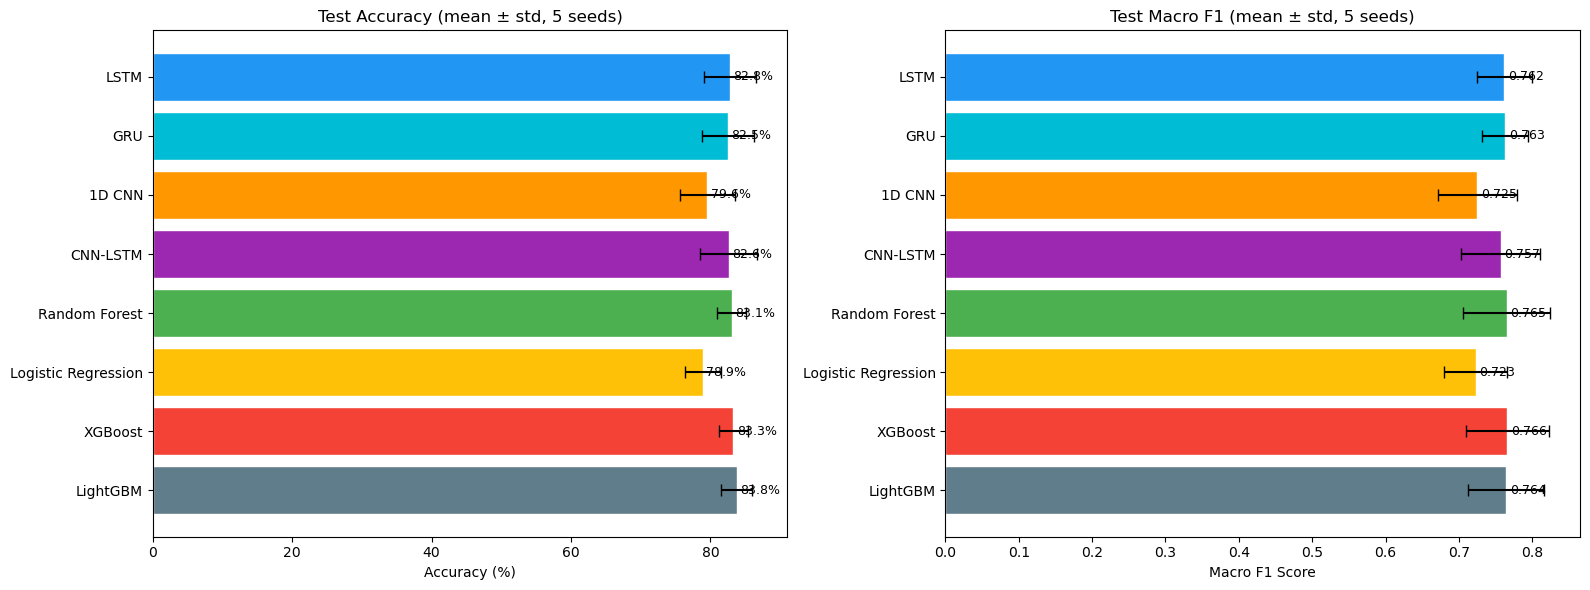

Saved → model_comparison.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#2196F3', '#00BCD4', '#FF9800', '#9C27B0',
          '#4CAF50', '#FFC107', '#F44336', '#607D8B']

ax = axes[0]
bars = ax.barh(summary_df['model'], summary_df['acc_mean'] * 100,
               xerr=summary_df['acc_std'] * 100,
               color=colors, edgecolor='white', capsize=4)
ax.set_xlabel('Accuracy (%)')
ax.set_title(f'Test Accuracy (mean ± std, {len(SEEDS)} seeds)')
ax.invert_yaxis()
for bar, val in zip(bars, summary_df['acc_mean']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%', va='center', fontsize=9)

ax = axes[1]
bars = ax.barh(summary_df['model'], summary_df['f1_mean'],
               xerr=summary_df['f1_std'],
               color=colors, edgecolor='white', capsize=4)
ax.set_xlabel('Macro F1 Score')
ax.set_title(f'Test Macro F1 (mean ± std, {len(SEEDS)} seeds)')
ax.invert_yaxis()
for bar, val in zip(bars, summary_df['f1_mean']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → model_comparison.png')

In [15]:
rows = []
for i, s in enumerate(SEEDS):
    row = {'Seed': s}
    for name in MODEL_NAMES:
        row[f'{name} Acc'] = f"{results[i][f'{name}_acc']*100:.2f}%"
        row[f'{name} F1']  = f"{results[i][f'{name}_f1']:.3f}"
    rows.append(row)

per_seed_df = pd.DataFrame(rows).set_index('Seed')
per_seed_df

,LSTM Acc,LSTM F1,GRU Acc,GRU F1,1D CNN Acc,1D CNN F1,CNN-LSTM Acc,CNN-LSTM F1,Random Forest Acc,Random Forest F1,Logistic Regression Acc,Logistic Regression F1,XGBoost Acc,XGBoost F1,LightGBM Acc,LightGBM F1
Seed,,,,,,,,,,,,,,,,
42,77.53%,0.714,76.35%,0.710,76.24%,0.708,77.41%,0.719,79.06%,0.720,75.76%,0.706,80.35%,0.726,81.29%,0.737
0,87.97%,0.829,85.62%,0.800,85.84%,0.812,87.75%,0.856,84.88%,0.846,83.71%,0.777,86.05%,0.851,85.73%,0.847
1,82.01%,0.763,80.39%,0.758,74.74%,0.703,80.05%,0.749,83.85%,0.799,78.55%,0.741,82.01%,0.781,81.31%,0.775
2,80.56%,0.756,83.26%,0.787,79.74%,0.750,80.56%,0.761,82.90%,0.781,78.81%,0.742,82.90%,0.787,83.84%,0.774
3,85.87%,0.748,86.82%,0.761,81.24%,0.651,87.17%,0.700,84.56%,0.679,77.79%,0.649,85.15%,0.685,86.70%,0.689
